# GBMEncoder 完整使用教程

本教程演示 `hscredit.core.encoders.GBMEncoder` 的完整使用方法，包括：

1. **基础用法** - XGBoost/LightGBM/CatBoost 三种模型
2. **输出类型** - leaves/onehot/probability/embedding 四种格式
3. **GBM + LR** - 梯度提升树 + 逻辑回归组合模型
4. **特征工程** - 获取特征重要性和树结构可视化
5. **缺失值处理** - 原生支持缺失值的优雅处理
6. **Pipeline集成** - 与 sklearn 无缝集成

In [1]:
# 导入必要的库
import sys
sys.path.insert(0, '/Users/xiaoxi/CodeBuddy/hscredit/hscredit')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.pipeline import Pipeline

from hscredit.core.encoders import GBMEncoder
from hscredit.core.models import LogisticRegression

print("✓ 所有库导入成功")

✓ 所有库导入成功


## 1. 准备示例数据

创建包含数值特征和类别特征的模拟数据集，并人为引入缺失值。

In [2]:
# 创建分类数据集
X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_clusters_per_class=1,
    flip_y=0.1,
    random_state=42
)

# 转换为DataFrame
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# 添加类别特征
np.random.seed(42)
df['category_A'] = np.random.choice(['A', 'B', 'C', 'D'], size=len(df))
df['category_B'] = np.random.choice(['X', 'Y', 'Z'], size=len(df))

# 人为引入缺失值（10%的样本）
missing_indices = np.random.choice(df.index, size=int(len(df) * 0.1), replace=False)
df.loc[missing_indices[:len(missing_indices)//2], 'feature_0'] = np.nan
df.loc[missing_indices[len(missing_indices)//2:], 'feature_1'] = np.nan

# 划分训练集和测试集
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['target'])

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']
X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

print(f"训练集大小: {len(X_train)}")
print(f"测试集大小: {len(X_test)}")
print(f"特征数量: {X_train.shape[1]}")
print(f"\n训练集缺失值统计:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

训练集大小: 3500
测试集大小: 1500
特征数量: 12

训练集缺失值统计:
feature_0    185
feature_1    167
dtype: int64


## 2. GBMEncoder 基础用法

### 2.1 核心参数说明

| 参数名 | 类型 | 默认值 | 说明 |
|--------|------|--------|------|
| `model_type` | str | 'xgboost' | 模型类型: 'xgboost'/'lightgbm'/'catboost' |
| `n_estimators` | int | 100 | 树的数量 |
| `max_depth` | int | 5 | 树的最大深度 |
| `learning_rate` | float | 0.1 | 学习率 |
| `output_type` | str | 'leaves' | 输出类型: 'leaves'/'onehot'/'probability'/'embedding' |
| `drop_origin` | bool | True | 是否删除原始特征 |
| `task` | str | 'classification' | 任务类型: 'classification'/'regression' |

### 2.2 XGBoost + Leaves 输出

最常用的组合，将样本在每棵树上的叶子节点索引作为新特征。

In [3]:
# 创建 XGBoost Encoder
xgb_encoder = GBMEncoder(
    model_type='xgboost',
    n_estimators=30,
    max_depth=4,
    learning_rate=0.1,
    output_type='leaves',
    drop_origin=True,
    random_state=42
)

# 拟合并转换
X_train_xgb = xgb_encoder.fit_transform(X_train, y_train)
X_test_xgb = xgb_encoder.transform(X_test)

print(f"原始特征数: {X_train.shape[1]}")
print(f"编码后特征数: {X_train_xgb.shape[1]}")
print(f"\n编码后的特征列:")
print(X_train_xgb.columns.tolist()[:10], "...")
print(f"\n编码后数据预览:")
X_train_xgb.head()

警告: 2 个特征存在缺失值，GBM将自动处理
原始特征数: 12
编码后特征数: 30

编码后的特征列:
['gbm_tree_0', 'gbm_tree_1', 'gbm_tree_2', 'gbm_tree_3', 'gbm_tree_4', 'gbm_tree_5', 'gbm_tree_6', 'gbm_tree_7', 'gbm_tree_8', 'gbm_tree_9'] ...

编码后数据预览:


,gbm_tree_0,gbm_tree_1,gbm_tree_2,gbm_tree_3,gbm_tree_4,gbm_tree_5,gbm_tree_6,gbm_tree_7,gbm_tree_8,gbm_tree_9,...,gbm_tree_20,gbm_tree_21,gbm_tree_22,gbm_tree_23,gbm_tree_24,gbm_tree_25,gbm_tree_26,gbm_tree_27,gbm_tree_28,gbm_tree_29
2937,11.0,11.0,19.0,16.0,20.0,19.0,20.0,20.0,19.0,11.0,...,13.0,14.0,17.0,12.0,15.0,17.0,15.0,10.0,11.0,14.0
1347,14.0,13.0,14.0,16.0,14.0,13.0,9.0,14.0,17.0,16.0,...,11.0,10.0,16.0,15.0,13.0,14.0,13.0,4.0,14.0,4.0
3817,16.0,17.0,15.0,7.0,17.0,16.0,15.0,16.0,8.0,17.0,...,11.0,13.0,15.0,17.0,14.0,13.0,13.0,13.0,14.0,4.0
3899,16.0,17.0,15.0,8.0,17.0,16.0,18.0,16.0,18.0,17.0,...,11.0,13.0,15.0,17.0,14.0,13.0,13.0,16.0,14.0,4.0
1232,11.0,11.0,19.0,17.0,21.0,20.0,22.0,19.0,11.0,11.0,...,5.0,11.0,21.0,11.0,15.0,15.0,16.0,10.0,16.0,14.0


### 2.3 LightGBM + OneHot 输出

将叶子节点进行独热编码，生成稀疏特征。

In [4]:
# 创建 LightGBM Encoder
lgb_encoder = GBMEncoder(
    model_type='lightgbm',
    n_estimators=20,
    max_depth=3,
    output_type='onehot',
    random_state=42
)

# 拟合并转换
X_train_lgb = lgb_encoder.fit_transform(X_train, y_train)
X_test_lgb = lgb_encoder.transform(X_test)

print(f"原始特征数: {X_train.shape[1]}")
print(f"OneHot编码后特征数: {X_train_lgb.shape[1]}")
print(f"\n前10个特征列:")
print(X_train_lgb.columns[:10].tolist())
print(f"\nOneHot编码后数据形状: {X_train_lgb.shape}")

警告: 2 个特征存在缺失值，GBM将自动处理
原始特征数: 12
OneHot编码后特征数: 158

前10个特征列:
['gbm_tree0_leaf0', 'gbm_tree0_leaf1', 'gbm_tree0_leaf2', 'gbm_tree0_leaf3', 'gbm_tree0_leaf4', 'gbm_tree0_leaf5', 'gbm_tree0_leaf6', 'gbm_tree0_leaf7', 'gbm_tree1_leaf0', 'gbm_tree1_leaf1']

OneHot编码后数据形状: (3500, 158)


### 2.4 CatBoost + Probability 输出

CatBoost 天然支持类别特征，输出预测概率。

In [5]:
# 创建 CatBoost Encoder
catb_encoder = GBMEncoder(
    model_type='catboost',
    n_estimators=50,
    max_depth=5,
    output_type='probability',
    random_state=42
)

# 拟合并转换
X_train_catb = catb_encoder.fit_transform(X_train, y_train)
X_test_catb = catb_encoder.transform(X_test)

print(f"原始特征数: {X_train.shape[1]}")
print(f"Probability输出特征数: {X_train_catb.shape[1]}")
print(f"\n特征列: {X_train_catb.columns.tolist()}")
print(f"\n预测概率分布:")
print(X_train_catb.describe())

警告: 2 个特征存在缺失值，GBM将自动处理
原始特征数: 12
Probability输出特征数: 1

特征列: ['gbm_proba']

预测概率分布:
         gbm_proba
count  3500.000000
mean      0.500057
std       0.377685
min       0.034124
25%       0.082159
50%       0.543213
75%       0.901476
max       0.950994


### 2.5 Embedding 输出

将每棵树的输出作为 embedding 的一个维度。

In [6]:
# 创建 Embedding Encoder
emb_encoder = GBMEncoder(
    model_type='xgboost',
    n_estimators=25,
    max_depth=4,
    output_type='embedding',
    random_state=42
)

# 拟合并转换
X_train_emb = emb_encoder.fit_transform(X_train, y_train)

print(f"原始特征数: {X_train.shape[1]}")
print(f"Embedding维度: {X_train_emb.shape[1]}")
print(f"\nEmbedding特征示例:")
X_train_emb.head()

警告: 2 个特征存在缺失值，GBM将自动处理
原始特征数: 12
Embedding维度: 25

Embedding特征示例:


,gbm_emb_0,gbm_emb_1,gbm_emb_2,gbm_emb_3,gbm_emb_4,gbm_emb_5,gbm_emb_6,gbm_emb_7,gbm_emb_8,gbm_emb_9,...,gbm_emb_15,gbm_emb_16,gbm_emb_17,gbm_emb_18,gbm_emb_19,gbm_emb_20,gbm_emb_21,gbm_emb_22,gbm_emb_23,gbm_emb_24
2937,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,1
1347,1,1,1,1,1,1,1,1,0,1,...,0,1,1,1,1,0,1,1,1,1
3817,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3899,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1232,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


## 3. GBM + LR 组合模型

经典的 Facebook GBDT + LR 方案：用 GBM 提取特征，输入逻辑回归。

In [7]:
# 创建 GBM + LR Pipeline
gbm_lr_pipeline = Pipeline([
    ('gbm_encoder', GBMEncoder(
        model_type='xgboost',
        n_estimators=30,
        max_depth=3,
        output_type='leaves',
        random_state=42
    )),
    ('lr', LogisticRegression(max_iter=1000, C=1.0))
])

# 训练
gbm_lr_pipeline.fit(X_train, y_train)

# 预测
y_pred_proba = gbm_lr_pipeline.predict_proba(X_test)[:, 1]
y_pred = gbm_lr_pipeline.predict(X_test)

# 评估
auc = roc_auc_score(y_test, y_pred_proba)
acc = accuracy_score(y_test, y_pred)

print(f"GBM + LR 组合模型性能:")
print(f"  AUC: {auc:.4f}")
print(f"  Accuracy: {acc:.4f}")
print(f"\n分类报告:")
print(classification_report(y_test, y_pred))

警告: 2 个特征存在缺失值，GBM将自动处理
GBM + LR 组合模型性能:
  AUC: 0.9359
  Accuracy: 0.8893

分类报告:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       751
           1       0.88      0.90      0.89       749

    accuracy                           0.89      1500
   macro avg       0.89      0.89      0.89      1500
weighted avg       0.89      0.89      0.89      1500



### 与纯 GBM 和纯 LR 对比

In [8]:
# 纯 XGBoost
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    n_estimators=30,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

# 需要处理类别特征和缺失值
X_train_xgb_pure = X_train.copy()
X_test_xgb_pure = X_test.copy()

# 简单编码类别特征
for col in ['category_A', 'category_B']:
    X_train_xgb_pure[col] = X_train_xgb_pure[col].astype('category').cat.codes
    X_test_xgb_pure[col] = X_test_xgb_pure[col].astype('category').cat.codes

xgb_model.fit(X_train_xgb_pure, y_train)
y_pred_xgb = xgb_model.predict_proba(X_test_xgb_pure)[:, 1]

# 纯 LR（需要填充缺失值）- 只填充数值列
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

# 只填充数值列
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
X_train_lr[numeric_cols] = X_train_lr[numeric_cols].fillna(X_train[numeric_cols].mean())
X_test_lr[numeric_cols] = X_test_lr[numeric_cols].fillna(X_train[numeric_cols].mean())

for col in ['category_A', 'category_B']:
    X_train_lr[col] = X_train_lr[col].astype('category').cat.codes
    X_test_lr[col] = X_test_lr[col].astype('category').cat.codes

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_lr, y_train)
y_pred_lr = lr_model.predict_proba(X_test_lr)[:, 1]

# 对比结果
print("模型性能对比:")
print("=" * 50)
print(f"{'模型':<20} {'AUC':<10}")
print("-" * 50)
print(f"{'GBM + LR':<20} {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"{'纯 XGBoost':<20} {roc_auc_score(y_test, y_pred_xgb):.4f}")
print(f"{'纯 LR':<20} {roc_auc_score(y_test, y_pred_lr):.4f}")

模型性能对比:
模型                   AUC       
--------------------------------------------------
GBM + LR             0.9359
纯 XGBoost            0.9507
纯 LR                 0.9240


## 4. 特征重要性分析

获取 GBM 模型的特征重要性。

警告: 2 个特征存在缺失值，GBM将自动处理
特征重要性 Top 10:
     feature  importance
2  feature_2    0.360945
0  feature_0    0.178309
9  feature_9    0.141442
8  feature_8    0.078199
5  feature_5    0.075978
7  feature_7    0.046545
6  feature_6    0.033125
1  feature_1    0.027285
4  feature_4    0.020420
3  feature_3    0.015390


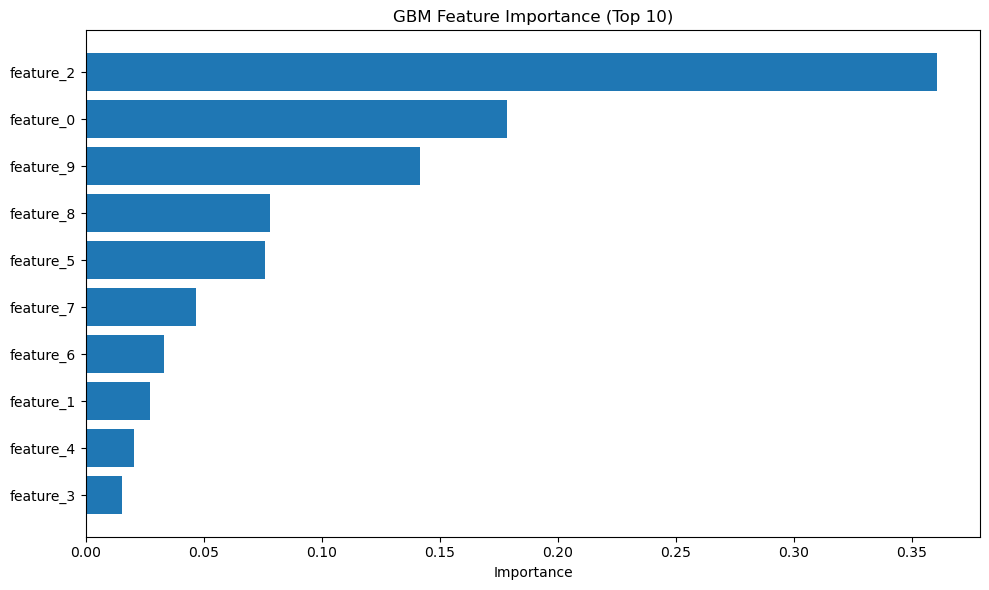

In [9]:
# 创建并训练 encoder
encoder = GBMEncoder(
    model_type='xgboost',
    n_estimators=50,
    max_depth=5,
    output_type='leaves',
    random_state=42
)
encoder.fit(X_train, y_train)

# 获取特征重要性
importance_df = encoder.get_feature_importance()
print("特征重要性 Top 10:")
print(importance_df.head(10))

# 可视化
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][:10][::-1], importance_df['importance'][:10][::-1])
plt.xlabel('Importance')
plt.title('GBM Feature Importance (Top 10)')
plt.tight_layout()
plt.show()

## 5. 缺失值处理

GBMEncoder 原生支持缺失值处理，无需手动填充。

In [10]:
# 查看缺失值统计
print("训练集缺失值统计:")
missing_stats = encoder.get_missing_stats()
print(missing_stats)

# 三种 GBM 模型对缺失值的处理对比
models = ['xgboost', 'lightgbm', 'catboost']
results = []

for model_type in models:
    enc = GBMEncoder(
        model_type=model_type,
        n_estimators=30,
        max_depth=4,
        output_type='probability',
        random_state=42
    )
    enc.fit(X_train, y_train)
    X_test_enc = enc.transform(X_test)
    
    # 使用 probability 输出评估
    proba = X_test_enc['gbm_proba'].values
    auc = roc_auc_score(y_test, proba)
    results.append({'Model': model_type, 'AUC': auc})

results_df = pd.DataFrame(results)
print("\n不同模型对缺失值的处理性能:")
print(results_df)

训练集缺失值统计:
     feature  missing_count  missing_ratio
0  feature_0            185       0.052857
1  feature_1            167       0.047714
警告: 2 个特征存在缺失值，GBM将自动处理
警告: 2 个特征存在缺失值，GBM将自动处理
警告: 2 个特征存在缺失值，GBM将自动处理

不同模型对缺失值的处理性能:
      Model       AUC
0   xgboost  0.950957
1  lightgbm  0.950736
2  catboost  0.948939


### 缺失值处理效果对比

In [11]:
# 对比：有缺失值 vs 填充缺失值
# 只填充数值列的缺失值
X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

numeric_cols = X_train.select_dtypes(include=[np.number]).columns
X_train_filled[numeric_cols] = X_train_filled[numeric_cols].fillna(X_train[numeric_cols].mean())
X_test_filled[numeric_cols] = X_test_filled[numeric_cols].fillna(X_train[numeric_cols].mean())

# 类别特征编码
for col in ['category_A', 'category_B']:
    X_train_filled[col] = X_train_filled[col].astype('category').cat.codes
    X_test_filled[col] = X_test_filled[col].astype('category').cat.codes

results_comparison = []

for model_type in ['xgboost', 'lightgbm']:
    # 处理缺失值版本
    enc_missing = GBMEncoder(
        model_type=model_type,
        n_estimators=30,
        max_depth=4,
        output_type='probability',
        random_state=42
    )
    enc_missing.fit(X_train, y_train)
    proba_missing = enc_missing.transform(X_test)['gbm_proba'].values
    auc_missing = roc_auc_score(y_test, proba_missing)
    
    # 填充缺失值版本
    enc_filled = GBMEncoder(
        model_type=model_type,
        n_estimators=30,
        max_depth=4,
        output_type='probability',
        random_state=42
    )
    enc_filled.fit(X_train_filled, y_train)
    proba_filled = enc_filled.transform(X_test_filled)['gbm_proba'].values
    auc_filled = roc_auc_score(y_test, proba_filled)
    
    results_comparison.append({
        'Model': model_type,
        'With Missing': auc_missing,
        'Filled Missing': auc_filled
    })

comparison_df = pd.DataFrame(results_comparison)
print("缺失值处理对比:")
print(comparison_df)

警告: 2 个特征存在缺失值，GBM将自动处理


AttributeError: 'NoneType' object has no attribute 'predict_proba'

## 6. 树结构可视化

可视化 GBM 中的单棵树结构。

警告: 2 个特征存在缺失值，GBM将自动处理
绘制 XGBoost 第一棵树...


ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

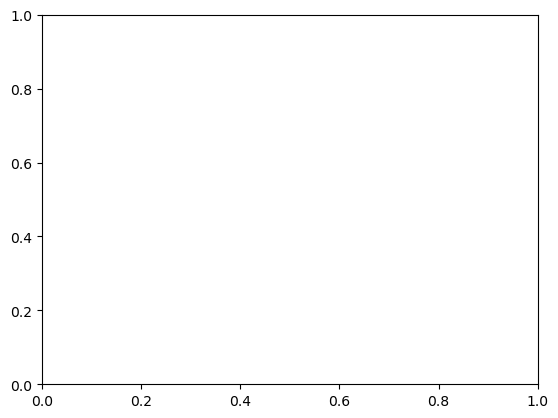

In [12]:
# 创建 XGBoost Encoder 并训练
viz_encoder = GBMEncoder(
    model_type='xgboost',
    n_estimators=10,
    max_depth=3,
    output_type='leaves',
    random_state=42
)
viz_encoder.fit(X_train, y_train)

# 可视化第一棵树
print("绘制 XGBoost 第一棵树...")
viz_encoder.plot_tree(tree_idx=0)
plt.title('XGBoost Tree Visualization')
plt.show()

警告: 2 个特征存在缺失值，GBM将自动处理
绘制 LightGBM 第一棵树...


ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

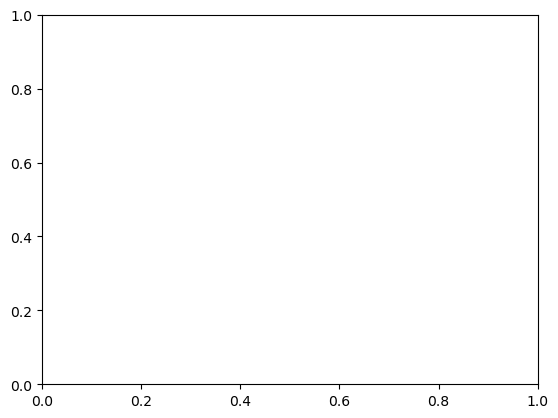

In [13]:
# LightGBM 树可视化
lgb_viz_encoder = GBMEncoder(
    model_type='lightgbm',
    n_estimators=10,
    max_depth=3,
    output_type='leaves',
    random_state=42
)
lgb_viz_encoder.fit(X_train, y_train)

print("绘制 LightGBM 第一棵树...")
lgb_viz_encoder.plot_tree(tree_idx=0)
plt.title('LightGBM Tree Visualization')
plt.show()

## 7. 高级用法

### 7.1 指定编码列

只选择部分特征进行 GBM 编码。

In [14]:
# 只选择数值特征进行编码
numeric_cols = [col for col in X_train.columns if col.startswith('feature_')]
print(f"选择的特征: {numeric_cols}")

selective_encoder = GBMEncoder(
    cols=numeric_cols,  # 只编码这些列
    model_type='xgboost',
    n_estimators=20,
    max_depth=3,
    output_type='leaves',
    drop_origin=False,  # 保留原始特征
    random_state=42
)

X_train_selective = selective_encoder.fit_transform(X_train, y_train)

print(f"\n原始特征数: {X_train.shape[1]}")
print(f"编码后特征数: {X_train_selective.shape[1]}")
print(f"\n所有特征列:")
print(X_train_selective.columns.tolist())

选择的特征: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']
警告: 2 个特征存在缺失值，GBM将自动处理

原始特征数: 12
编码后特征数: 32

所有特征列:
['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'category_A', 'category_B', 'gbm_tree_0', 'gbm_tree_1', 'gbm_tree_2', 'gbm_tree_3', 'gbm_tree_4', 'gbm_tree_5', 'gbm_tree_6', 'gbm_tree_7', 'gbm_tree_8', 'gbm_tree_9', 'gbm_tree_10', 'gbm_tree_11', 'gbm_tree_12', 'gbm_tree_13', 'gbm_tree_14', 'gbm_tree_15', 'gbm_tree_16', 'gbm_tree_17', 'gbm_tree_18', 'gbm_tree_19']


### 7.2 自定义模型参数

通过 `model_params` 传入额外的模型参数。

In [15]:
# 使用自定义参数
custom_encoder = GBMEncoder(
    model_type='xgboost',
    n_estimators=50,
    max_depth=6,
    output_type='probability',
    model_params={
        'reg_alpha': 0.1,        # L1 正则化
        'reg_lambda': 1.0,       # L2 正则化
        'gamma': 0.1,            # 最小分裂损失
        'scale_pos_weight': 1,   # 正样本权重
    },
    random_state=42
)

custom_encoder.fit(X_train, y_train)
proba = custom_encoder.transform(X_test)['gbm_proba'].values

print(f"自定义参数模型 AUC: {roc_auc_score(y_test, proba):.4f}")
print(f"\n训练好的模型参数:")
print(custom_encoder.get_model().get_params())

警告: 2 个特征存在缺失值，GBM将自动处理
自定义参数模型 AUC: 0.9546

训练好的模型参数:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'gamma': 0.1, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': 20, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 50, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': 1, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


### 7.3 回归任务

GBMEncoder 也支持回归任务。

In [18]:
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score

# 创建回归数据集
X_reg, y_reg = make_regression(
    n_samples=2000,
    n_features=8,
    n_informative=5,
    noise=10,
    random_state=42
)

df_reg = pd.DataFrame(X_reg, columns=[f'feat_{i}' for i in range(X_reg.shape[1])])
df_reg['target'] = y_reg

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    df_reg.drop('target', axis=1), df_reg['target'], test_size=0.3, random_state=42
)

# 创建回归 Encoder
reg_encoder = GBMEncoder(
    model_type='lightgbm',
    n_estimators=50,
    max_depth=5,
    output_type='embedding',
    task='regression',
    random_state=42
)

# 训练并转换
X_reg_train_enc = reg_encoder.fit_transform(X_reg_train, y_reg_train)
X_reg_test_enc = reg_encoder.transform(X_reg_test)

print(f"回归任务 - Embedding 维度: {X_reg_train_enc.shape[1]}")

# 使用 embedding 训练线性回归
from sklearn.linear_model import LinearRegression
lr_reg = LinearRegression()
lr_reg.fit(X_reg_train_enc, y_reg_train)
y_reg_pred = lr_reg.predict(X_reg_test_enc)

mse = mean_squared_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"\nGBM Embedding + Linear Regression:")
print(f"  MSE: {mse:.2f}")
print(f"  R²: {r2:.4f}")

AttributeError: 'NoneType' object has no attribute 'predict'

## 8. 完整工作流示例

将以上所有功能组合成一个完整的工作流。

In [ ]:
# 完整工作流：GBM 特征工程 + 模型训练 + 评估

def gbm_feature_engineering_workflow(X_train, X_test, y_train, y_test, model_type='xgboost'):
    """
    完整的 GBM 特征工程工作流
    """
    results = {}
    
    # 1. 创建不同输出类型的 encoder
    output_types = ['leaves', 'probability', 'embedding']
    
    for output_type in output_types:
        encoder = GBMEncoder(
            model_type=model_type,
            n_estimators=30,
            max_depth=4,
            output_type=output_type,
            random_state=42
        )
        
        # 拟合
        X_train_enc = encoder.fit_transform(X_train, y_train)
        X_test_enc = encoder.transform(X_test)
        
        # 训练 LR
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_train_enc, y_train)
        
        # 评估
        y_pred_proba = lr.predict_proba(X_test_enc)[:, 1]
        auc = roc_auc_score(y_test, y_pred_proba)
        
        results[output_type] = {
            'encoder': encoder,
            'feature_count': X_train_enc.shape[1],
            'auc': auc
        }
    
    return results

# 执行工作流
workflow_results = gbm_feature_engineering_workflow(X_train, X_test, y_train, y_test, model_type='xgboost')

# 展示结果
print("不同输出类型性能对比:")
print("=" * 60)
print(f"{'Output Type':<20} {'Feature Count':<15} {'AUC':<10}")
print("-" * 60)
for output_type, result in workflow_results.items():
    print(f"{output_type:<20} {result['feature_count']:<15} {result['auc']:.4f}")

## 9. 总结

本教程演示了 GBMEncoder 的核心功能：

1. **三种 GBM 模型**：XGBoost、LightGBM、CatBoost
2. **四种输出类型**：
   - `leaves`：叶子节点索引，最常用
   - `onehot`：独热编码，适用于稀疏特征场景
   - `probability`：预测概率，可直接作为特征
   - `embedding`：树路径 embedding，适用于深度学习
3. **GBM + LR 组合**：经典的特征提取 + 线性模型方案
4. **缺失值处理**：原生支持，无需预处理
5. **特征重要性**：可解释的特征贡献度分析
6. **可视化**：支持树结构可视化

### 推荐使用场景

- **信用评分**：GBM + LR 是业界标准方案
- **特征工程**：将树模型的叶子节点作为新特征
- **高基数类别特征**：CatBoost 原生支持
- **缺失值较多**：无需填充，自动处理